In [4]:
#install the required libraries
!pip install opencv-python
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install tensorflow
!pip install scikit-learn

In [5]:
#Load MNIST Dataset to train the model to recognize handwritten digits
import tensorflow as tf
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [6]:
#Normalize the images by converting pixel values from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
#Reshape the images: CNN models expect a channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [8]:
#Build the CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential()

model.add(Conv2D(32,
                  (3, 3),
                 activation='relu',
                 input_shape=(28, 28, 1)))

model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))

model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
#Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
#Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 20ms/step - accuracy: 0.9553 - loss: 0.1496 - val_accuracy: 0.9772 - val_loss: 0.0668
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9842 - loss: 0.0521 - val_accuracy: 0.9843 - val_loss: 0.0477
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9901 - loss: 0.0320 - val_accuracy: 0.9847 - val_loss: 0.0410
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.9935 - loss: 0.0212 - val_accuracy: 0.9865 - val_loss: 0.0415
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9957 - loss: 0.0141 - val_accuracy: 0.9876 - val_loss: 0.0402


In [11]:
#Save the model
model.save("handwritten_grading_model.keras")

# EVALUATE THE MODEL

In [12]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('handwritten_grading_model.keras')

# Evaluate the loaded model on the test set
loss, accuracy = loaded_model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9876 - loss: 0.0402
Test Loss: 0.0402
Test Accuracy: 0.9876


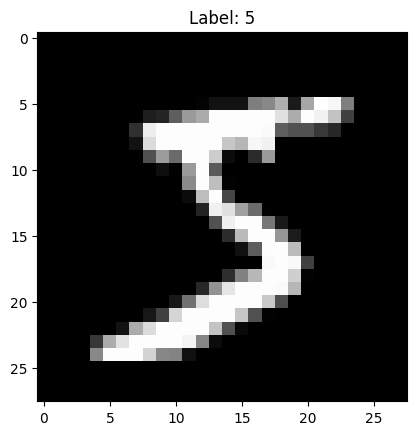

In [13]:
#Visualize a sample digit
import matplotlib.pyplot as plt

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.show()

In [14]:
#Load the saved model
from tensorflow.keras.models import load_model
model = load_model(
    "handwritten_grading_model.keras"
)

In [15]:
#Load and read the student's answer sheet
import cv2
img = cv2.imread("/content/Chisom.jpg",)
print(img.shape)

(1280, 962, 3)


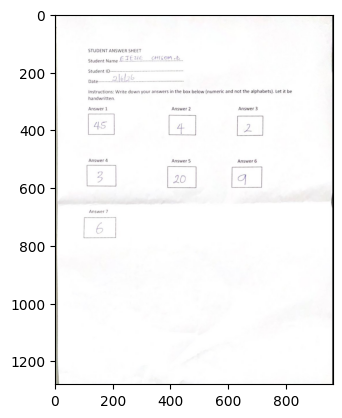

In [109]:
#Display the image via graph
import matplotlib.pyplot as plt
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

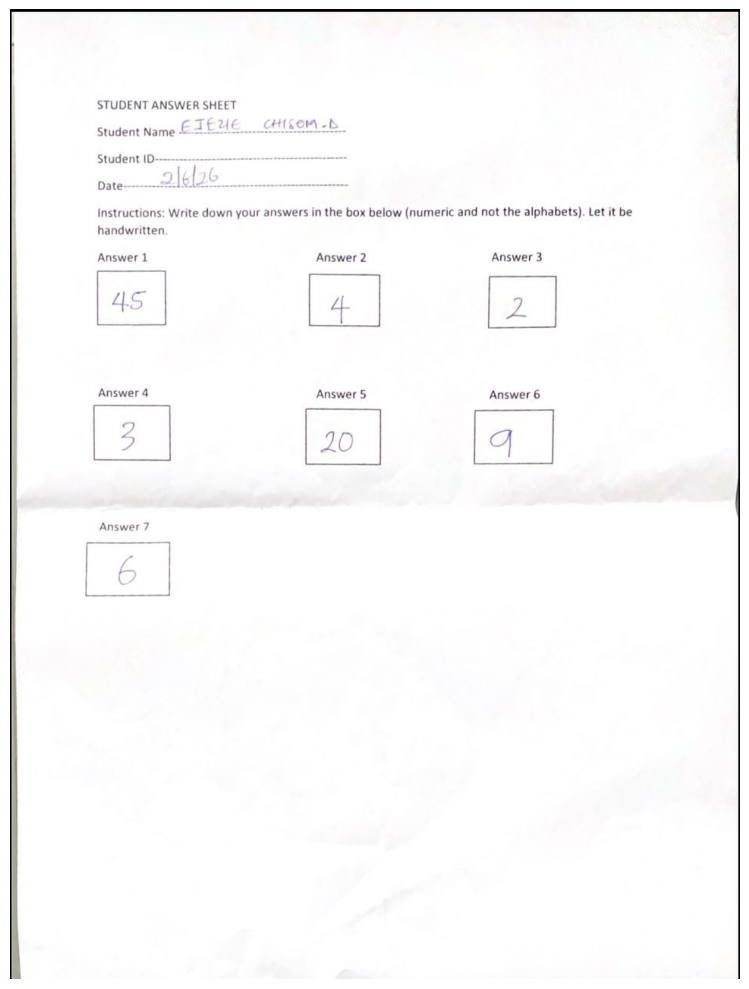

In [110]:
#Display the image without graph
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.tight_layout()
plt.show()

In [125]:
#Crop each answer box by method of hardcoding the box positions
boxes = {
    "A1": (50, 50, 150, 100),
    "A2": (50, 150, 150, 200),
    "A3": (50, 250, 150, 300),
    "A4": (50, 350, 150, 400),
    "A5": (50, 450, 150, 500),
    "A6": (50, 550, 150, 600),
    "A7": (50, 650, 150, 700),
}

cropped_answers = {}
#Save the cropped boxes; each image contains one answer box
for key, (x1, y1, x2, y2) in boxes.items():
    crop = img[y1:y2, x1:x2]
    cropped_answers[key] = crop
for key, crop in cropped_answers.items():
   cv2.imwrite(f"{key}.jpg", crop)
   #Convert to Grayscale
   gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
   #Threshold the image to reduce background noise
   _, thresh = cv2.threshold(
    gray,
    150,
    255,
    cv2.THRESH_BINARY_INV
)
   #Find individual digits; each contour represents a digit
   contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)
   #Sort didgits from left to right; this ensures 4 then 5 instead of 5 then 4
   contours = sorted(
    contours,
    key=lambda c: cv2.boundingRect(c)[0]
    )
   #Extract each digit
   digits = []
   for contour in contours:
    x,y,w,h = cv2.boundingRect(contour)
    digit = thresh[y:y+h, x:x+w]
    digits.append(digit)

In [119]:
#Resize to MNIST format; resize, normalize, reshape
predicted_digits = []

for digit_image in digits:
    digit_resized = cv2.resize(digit_image, (28, 28))
    digit_normalized = digit_resized / 255.0
    digit_reshaped = digit_normalized.reshape(1, 28, 28, 1)

    prediction = model.predict(digit_reshaped, verbose=0)
    number = prediction.argmax()

    print(number)
    predicted_digits.append(str(number))

print("Predicted digits:", predicted_digits)

4
3
2
1
5
2
1
Predicted digits: ['4', '3', '2', '1', '5', '2', '1']


In [122]:
#Predict each digit
prediction = model.predict(digit)
number = prediction.argmax()

print(number)
#Store predictions
predicted_digits.append(str(number))
#Reconstruct the answer
answer = "".join(predicted_digits)
print(answer)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1
43215211


In [127]:
#Process all boxes
predictions = {
    "A1": 45,
    "A2": 4,
    "A3": 2,
    "A4": 3,
    "A5": 20,
    "A6": 9,
    "A7": 6,
}

In [106]:
#Create marking scheme/answer key
answer_key = {
    "A1": 45,
    "A2": 11,
    "A3": 4,
    "A4": 2,
    "A5": 3,
    "A6": 25,
    "A7": 16,
}

In [128]:
#Grading of student
score = 0
for question in answer_key:
  if predictions[question] == answer_key[question]:
    score += 1
    #Display the result
    print("Score:", score)
    print("Total Questions:", len(answer_key))

Score: 1
Total Questions: 7
